## Table 4: ViT-Base model's results on CIFAR-100 dataset using RTX 5090 GPU

### Section 1: Loading Dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
vit_base_data=[]
vit_base_data_test=[]

for i in range(1,101):
    temp1=[]
    for j in range(10):
        path='./mem_csv_vit_base_cifar-100_5090/report'+str(j)+'_'+str(i)+'.csv'
        data=pd.read_csv(path)
        temp1.append(data)
    vit_base_data.append(temp1)


for i in range(1,31):
    temp1=[]
    for j in range(10):
        path='./mem_csv_vit_base_cifar-100_5090_test/report'+str(j)+'_'+str(i)+'.csv'
        data=pd.read_csv(path)
        temp1.append(data)
    vit_base_data_test.append(temp1)

print(vit_base_data[0][1].columns)
print(vit_base_data_test[0][1].columns)

Index(['ID', 'Process ID', 'Process Name', 'Host Name', 'Kernel Name',
       'Context', 'Stream', 'Block Size', 'Grid Size', 'Device',
       ...
       'syslts__t_tag_requests.avg.pct_of_peak_sustained_elapsed',
       'syslts__t_tag_requests.max.pct_of_peak_sustained_elapsed',
       'syslts__t_tag_requests.min.pct_of_peak_sustained_elapsed',
       'syslts__t_tag_requests.sum.pct_of_peak_sustained_elapsed',
       'syslts__xbar2syslts_cycles_active.avg.pct_of_peak_sustained_elapsed',
       'syslts__xbar2syslts_cycles_active.max.pct_of_peak_sustained_elapsed',
       'syslts__xbar2syslts_cycles_active.min.pct_of_peak_sustained_elapsed',
       'syslts__xbar2syslts_cycles_active.sum.pct_of_peak_sustained_elapsed',
       'thread_inst_executed', 'thread_inst_executed_true'],
      dtype='object', length=2062)
Index(['ID', 'Process ID', 'Process Name', 'Host Name', 'Kernel Name',
       'Context', 'Stream', 'Block Size', 'Grid Size', 'Device',
       ...
       'syslts__t_tag_requests

### Section 2: Pre-processing Dataset

In [3]:
for i in range(100):
    for j in range(10):
        vit_base_data[i][j]=vit_base_data[i][j].drop(['ID'], axis=1)
        if 0 in vit_base_data[i][j].index:
            vit_base_data[i][j] = vit_base_data[i][j].drop(index=0)

for i in range(30):
    for j in range(10):
        vit_base_data_test[i][j]=vit_base_data_test[i][j].drop(['ID'], axis=1)
        if 0 in vit_base_data_test[i][j].index:
            vit_base_data_test[i][j] = vit_base_data_test[i][j].drop(index=0)
            



In [4]:
vit_base_data_test[0][0]['Kernel Name'].unique

<bound method Series.unique of 1     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
2     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
3     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
4     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
5     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
6     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
7     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
8     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
9     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
10    fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
11    fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
12    fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
Name: Kernel Name, dtype: object>

### Section 3: Metric-based Data filtering and pre-processing

In [5]:
# Import additional libraries for visualization and random sampling
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import random
kernel_name=['fmha_cutlassF_f32_aligned_64x64_rf_sm80']
ltx_cols=[col for col in vit_base_data[0][1].columns if 
          col.startswith('smsp__inst_executed_op_branch.avg') 
          or col.startswith('smsp__inst_executed_op_branch.max') 
          or col.startswith('smsp__inst_executed_op_branch.min') 
          or col.startswith('smsp__inst_executed_op_branch.sum') 
          or col.startswith('smsp__inst_executed_op_shared_atom.sum') 
          or col.startswith('smsp__inst_executed_op_shared_atom.sum.pct_of_peak_sustained_elapsed') 
          or col.startswith('smsp__inst_issued.avg') 
          or col.startswith('smsp__inst_issued.max') 
          or col.startswith('smsp__inst_issued.min') 
          or col.startswith('smsp__inst_issued.sum') 
            or col.startswith('sm__inst_executed_pipe_cbu_pred_on_any')
          ]
for col in ltx_cols:
    for i in range(100):
        for j in range(10):
            if vit_base_data[i][j][col].dtype == 'object': 
                vit_base_data[i][j][col] = pd.to_numeric(vit_base_data[i][j][col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
    for i in range(30):
        for j in range(10):
            if vit_base_data_test[i][j][col].dtype == 'object':  
                vit_base_data_test[i][j][col] = pd.to_numeric(vit_base_data_test[i][j][col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
                

print(ltx_cols)

/home/t1000/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


['sm__inst_executed_pipe_cbu_pred_on_any.avg.pct_of_peak_sustained_elapsed', 'sm__inst_executed_pipe_cbu_pred_on_any.max.pct_of_peak_sustained_elapsed', 'sm__inst_executed_pipe_cbu_pred_on_any.min.pct_of_peak_sustained_elapsed', 'sm__inst_executed_pipe_cbu_pred_on_any.sum.pct_of_peak_sustained_elapsed', 'smsp__inst_executed_op_branch.avg', 'smsp__inst_executed_op_branch.max', 'smsp__inst_executed_op_branch.min', 'smsp__inst_executed_op_branch.sum', 'smsp__inst_executed_op_shared_atom.sum', 'smsp__inst_executed_op_shared_atom.sum.pct_of_peak_sustained_elapsed', 'smsp__inst_issued.avg', 'smsp__inst_issued.max', 'smsp__inst_issued.min', 'smsp__inst_issued.sum']


print(len(all_class_data))

In [6]:
vit_base_data[0][0].shape

(12, 2061)

### Section 4: Generating classifier model's training data and validation data by considering only the filtered Metrics.

In [7]:
col=[col for col in vit_base_data[0][1].columns if 
          col.startswith('smsp__inst_executed_op_branch.avg') 
          or col.startswith('smsp__inst_executed_op_branch.max') 
          or col.startswith('smsp__inst_executed_op_branch.min') 
          or col.startswith('smsp__inst_executed_op_branch.sum') 
          or col.startswith('smsp__inst_executed_op_shared_atom.sum') 
          or col.startswith('smsp__inst_executed_op_shared_atom.sum.pct_of_peak_sustained_elapsed') 
          or col.startswith('smsp__inst_issued.avg') 
          or col.startswith('smsp__inst_issued.max') 
          or col.startswith('smsp__inst_issued.min') 
          or col.startswith('smsp__inst_issued.sum') 
            or col.startswith('sm__inst_executed_pipe_cbu_pred_on_any')
          ]

for i in range(10):
    for j in range(10):
        for c in col:
            vit_base_data[i][j][c]=pd.to_numeric(vit_base_data[i][j][c].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float32')
            
for i in range(30):
    for j in range(10):
        for c in col:
            vit_base_data_test[i][j][c]=pd.to_numeric(vit_base_data_test[i][j][c].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float32')


vit_base_data_df=[[[] for i in range(10)] for j in range(100)]
vit_base_data_test_df=[[[] for i in range(10)] for j in range(30)]
for i in range(len(vit_base_data)):
    for j in range(len(vit_base_data[i])):
        df2 = vit_base_data[i][j]
        selected_cols = [c for c in col if c in df2.columns]
        vit_base_data_df[i][j] = vit_base_data[i][j][selected_cols].copy()

for i in range(len(vit_base_data_test)):
    for j in range(len(vit_base_data_test[i])):
        df2 = vit_base_data_test[i][j]
        selected_cols = [c for c in col if c in df2.columns]
        vit_base_data_test_df[i][j] = vit_base_data_test[i][j][selected_cols].copy()

In [8]:
print(col)

['sm__inst_executed_pipe_cbu_pred_on_any.avg.pct_of_peak_sustained_elapsed', 'sm__inst_executed_pipe_cbu_pred_on_any.max.pct_of_peak_sustained_elapsed', 'sm__inst_executed_pipe_cbu_pred_on_any.min.pct_of_peak_sustained_elapsed', 'sm__inst_executed_pipe_cbu_pred_on_any.sum.pct_of_peak_sustained_elapsed', 'smsp__inst_executed_op_branch.avg', 'smsp__inst_executed_op_branch.max', 'smsp__inst_executed_op_branch.min', 'smsp__inst_executed_op_branch.sum', 'smsp__inst_executed_op_shared_atom.sum', 'smsp__inst_executed_op_shared_atom.sum.pct_of_peak_sustained_elapsed', 'smsp__inst_issued.avg', 'smsp__inst_issued.max', 'smsp__inst_issued.min', 'smsp__inst_issued.sum']


In [9]:
vit_base_data_test_df[0][0].shape

(12, 14)

### Dataset re-arrangement and providing label for training and test samples for both shadow and target model. Also, selecting appropiate rnage of FMHA kernel instances for achieving maximum attack success rate.

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train=[]
y_train=[]
X_test=[]
y_test=[]

for i in range(100):
    for j in range(10):
        r = vit_base_data_df[i][j]  # shape: (12, 2)
        X_train.append(r)

        if i < 50:
            y_train.append(1)
        else:
            y_train.append(0)
for i in range(30):
    for j in range(10):
        r = vit_base_data_test_df[i][j]  # shape: (12, 2)
        X_test.append(r)

        if i < 15:
            y_test.append(1)
        else:
            y_test.append(0)


X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

X_train = X_train[:,0:12, :]
X_test = X_test[:, 0:12, :]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1000, 12, 14) (1000,)
(300, 12, 14) (300,)


In [11]:
print(X_train.dtype)
print(X_train[0, 0, :10]) 

float64
[5.71991980e-01 5.89980006e-01 5.60557008e-01 5.71991980e-01
 5.48065869e+03 5.68400000e+03 5.36600000e+03 3.72684800e+06
 5.11232000e+05 3.69910002e-02]


In [12]:
# Ensure all elements are float32
X_train = X_train.astype(np.float32)

In [13]:
import numpy as np
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([500, 500]))
(array([0, 1]), array([150, 150]))


### Attack Classifier training

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization
import numpy as np
from sklearn.model_selection import train_test_split

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  
def reset_random_seeds():
   os.environ['PYTHONHASHSEED']=str(42)
   tf.random.set_seed(42)
   np.random.seed(42)
   random.seed(42)


reset_random_seeds()
import tensorflow as tf

# Your input data shape: (samples, sequence_length, feature_dim)
num_samples = X_train.shape[0]
sequence_length = X_train.shape[1]
feature_dim = X_train.shape[2]

# Define the model
# Stacked BiLSTM Layers
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(sequence_length, feature_dim)))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(32, return_sequences=False)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))


# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True)
X_train = (X_train - mean) / (std + 1e-8)
# Summary
model.summary()
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
# Train
history = model.fit(
    X_train_split, y_train_split,
    epochs=90,
    batch_size=45,
    validation_data=(X_val_split, y_val_split)
)

2026-08-24 16:58:51.676843: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-24 16:58:51.703935: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-24 16:58:52.496344: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-24 16:58:52.602871: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 12, 128)        │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,889 (335.50 KB)

 Trainable params: 85,889 (335.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5500 - loss: 0.6894 - val_accuracy: 0.5250 - val_loss: 0.6889
Epoch 2/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5225 - loss: 0.6875 - val_accuracy: 0.6200 - val_loss: 0.6830
Epoch 3/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5562 - loss: 0.6764 - val_accuracy: 0.4900 - val_loss: 0.6799
Epoch 4/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5612 - loss: 0.6759 - val_accuracy: 0.5050 - val_loss: 0.6827
Epoch 5/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5650 - loss: 0.6697 - val_accuracy: 0.6300 - val_loss: 0.6640
Epoch 6/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5775 - loss: 0.6494 - val_accuracy: 0.5750 - val_loss: 0.6576
Epoch 7/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5713 - loss: 0.6457 - val_accuracy: 0.5950 - val_loss: 0.6519
Epoch 8/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6100 - loss: 0.6342 - val_accuracy: 0.5650 - val_loss

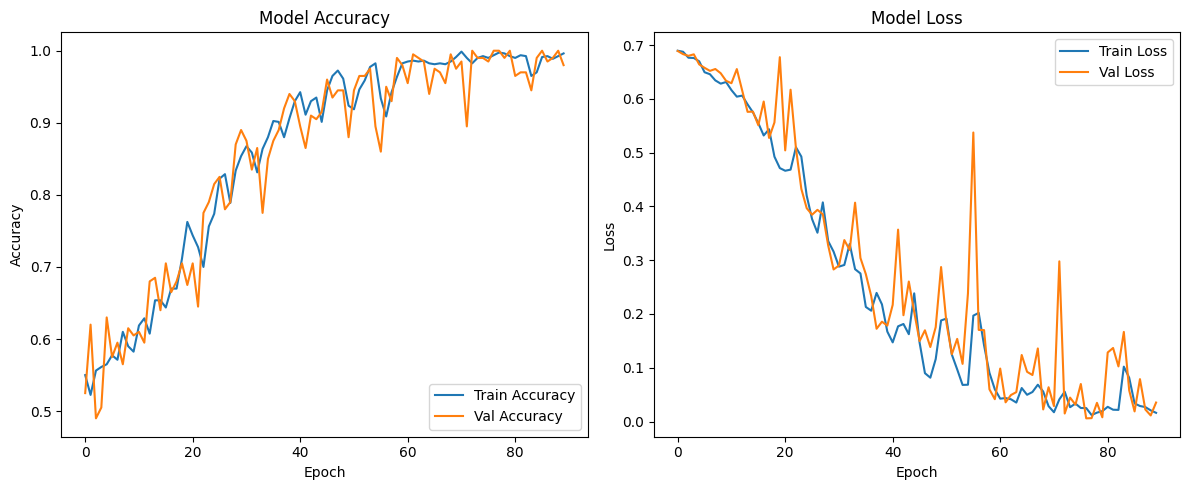

In [15]:

import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


### Membership Inference Attack on Target Model Data

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Test Accuracy: 0.9667
Confusion Matrix:
 [[144   6]
 [  4 146]]


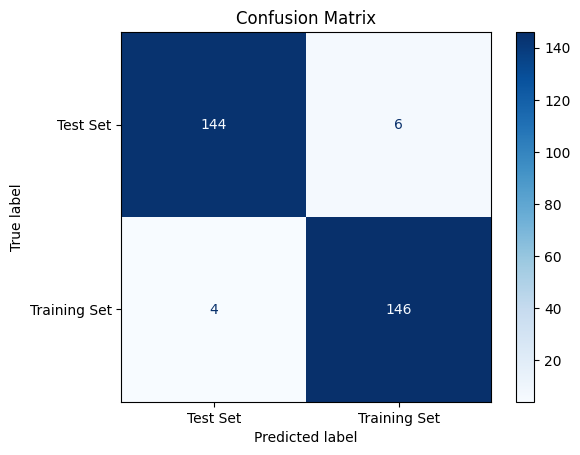

In [16]:
# Predict
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mean = X_test.mean(axis=(0, 1), keepdims=True)
std = X_test.std(axis=(0, 1), keepdims=True)
X_test = (X_test - mean) / (std + 1e-8)

# Predict probabilities
predictions = model.predict(X_test)

# # Convert probabilities to binary labels
predicted_labels = (predictions > 0.5).astype(int)

# Accuracy
acc = accuracy_score(y_test, predicted_labels)
print(f"Test Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, predicted_labels)
print("Confusion Matrix:\n", cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Test Set","Training Set"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

F1 Score: 0.9669
AUC Score: 0.9977


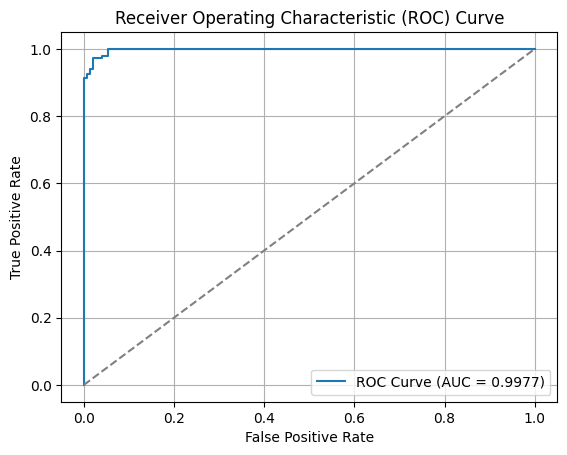

In [17]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score
)
import matplotlib.pyplot as plt
import numpy as np

# Binary predictions using threshold 0.5
predicted_labels = (predictions >= 0.5).astype(int)

# F1 Score
f1 = f1_score(y_test, predicted_labels)
print(f"F1 Score: {f1:.4f}")

# AUC Score
auc_score = roc_auc_score(y_test, predictions)
print(f"AUC Score: {auc_score:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, predictions)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Random chance line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
